# Static–dynamic split-half RSA — transparent workflow

Every analysis step is shown explicitly below. We load the individual repetitions, split repetitions independently within each stimulus, compute raw-response and RDM split-half consistency, and compare dynamic RDMs with static RDMs.

In [59]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.stats import rankdata

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config.yaml").is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find config.yaml above the notebook directory.")
    # end if PROJECT_ROOT.parent == PROJECT_ROOT
    PROJECT_ROOT = PROJECT_ROOT.parent
# end while not config.yaml exists
with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open
paths = config[ENV]["paths"]
sys.path.extend([paths["src_path"], paths["useful_stuff_path"]])

from project_specific_utils import load_raster
from useful_stuff.general_utils import TimeSeries, create_RDM, dRSA


In [60]:
@dataclass
class Cfg:
    static_exp_name: str = "baby1_260718to27" # "red_20260726to27" # 
    dynamic_exp_name: str = "baby1_260716to24" # "red_20260720to24"  #
    # Inclusive, one-based MATLAB channel range.
    good_channels: tuple[int, int] | None = (101, 109) # None #
    # Used only when good_channels is None; ranked by maximum video response.
    top_k: int | None = None #50
    static_crop_ms: float = 1000
    static_response: str = "last_frame"  # last_frame, 2000ms, or 2250ms
    dynamic_crop_ms: float | None = None
    source_fs: float = 1000
    new_fs: float = 100
    rdm_metric: str = "cosine_cnt"
    rsa_metric: str = "correlation"
    n_split_repeats: int = 10
    spearman_brown: bool = True
    # Target-length / single-split-length ratio; use 2 for split-half to full.
    spearman_brown_k: float = 2
    random_seed: int = 0
    static_reference_window_ms: tuple[float, float] = (0, 1000)

cfg = Cfg()
valid_static_responses = {"last_frame", "2000ms", "2250ms"}
if cfg.static_response not in valid_static_responses:
    raise ValueError(f"static_response must be one of {sorted(valid_static_responses)}.")
# end if cfg.static_response
if cfg.spearman_brown_k <= 0:
    raise ValueError("spearman_brown_k must be positive.")
# end if cfg.spearman_brown_k
data_dir = Path(paths["data_path"]) / "data"
static_path = data_dir / f"{cfg.static_exp_name}_raster_img.mat"
dynamic_path = data_dir / f"{cfg.dynamic_exp_name}_raster_vid.mat"
if cfg.good_channels is None:
    channel_slice = slice(None)
else:
    first_channel, last_channel = cfg.good_channels
    channel_slice = slice(first_channel - 1, last_channel)
# end if cfg.good_channels
static_end_sample = int(round(cfg.static_crop_ms * cfg.source_fs / 1000))
dynamic_end_sample = None if cfg.dynamic_crop_ms is None else int(round(cfg.dynamic_crop_ms * cfg.source_fs / 1000))
cfg


Cfg(static_exp_name='baby1_260718to27', dynamic_exp_name='baby1_260716to24', good_channels=(101, 109), top_k=None, static_crop_ms=1000, static_response='last_frame', dynamic_crop_ms=None, source_fs=1000, new_fs=100, rdm_metric='cosine_cnt', rsa_metric='correlation', n_split_repeats=10, spearman_brown=True, spearman_brown_k=2, random_seed=0, static_reference_window_ms=(0, 1000))

In [47]:
def resample_rasters(rasters, source_fs, target_fs):
    if source_fs == target_fs:
        return rasters
    # end if source_fs == target_fs
    series = TimeSeries(rasters, fs=source_fs)
    series.resample(target_fs)
    return series.get_array()
# EOF


def average_by_stimulus(rasters, identities, stimulus_order):
    means = []
    for identity in stimulus_order:
        indices = np.flatnonzero(np.asarray(identities) == identity)
        means.append(rasters[:, :, indices].mean(axis=2))
    # end for identity
    return np.stack(means, axis=2)
# EOF

"""
stimulus_identity
Extract a stimulus identity while retaining only the configured static response.

INPUT:
    - name: str -> presentation filename
    - condition: str -> static or dynamic

OUTPUT:
    - identity: str | None -> matched identity, or None for an excluded presentation
"""
def stimulus_identity(name, condition, static_response=None):
    if static_response is None:
        static_response = cfg.static_response
    # end if static_response
    stem = Path(name).stem
    if condition == "static":
        static_prefixes = {
            "last_frame": "img_",
            "2000ms": "img_2000ms_",
            "2250ms": "img_2250ms_",
        }
        if stem.startswith(static_prefixes["2000ms"]):
            response = "2000ms"
        elif stem.startswith(static_prefixes["2250ms"]):
            response = "2250ms"
        elif stem.startswith(static_prefixes["last_frame"]):
            response = "last_frame"
        else:
            return None
        # end if static filename prefix
        if response != static_response:
            return None
        # end if response != static_response
        prefix = static_prefixes[response]
    elif condition == "dynamic":
        prefix = "vid_"
    else:
        raise ValueError("condition must be 'static' or 'dynamic'.")
    # end if condition
    return stem[len(prefix):] if stem.startswith(prefix) else None
# EOF


def split_repetitions(rasters, identities, stimulus_order, rng):
    """Split and average repetitions separately for every stimulus."""
    indices_by_identity = {}
    for presentation_index, identity in enumerate(identities):
        indices_by_identity.setdefault(identity, []).append(presentation_index)
    # end for presentation_index, identity
    first_means, second_means = [], []
    for identity in stimulus_order:
        indices = np.asarray(indices_by_identity[identity], dtype=int)
        if len(indices) < 2:
            raise ValueError(f"{identity!r} has fewer than two repetitions.")
        # end if len(indices)
        indices = rng.permutation(indices)
        split_index = len(indices) // 2
        first_means.append(rasters[:, :, indices[:split_index]].mean(axis=2))
        second_means.append(rasters[:, :, indices[split_index:]].mean(axis=2))
    # end for identity
    return np.stack(first_means, axis=2), np.stack(second_means, axis=2)
# EOF


def spearman_brown_correction(correlation, k):
    """Predict reliability after changing test length by a factor of k."""
    return k * correlation / (1 + (k - 1) * correlation)
# EOF


"""
compute_split_half_reliability
Compute repeated time-resolved raw or RDM split-half reliability.

INPUT:
    - rasters: np.ndarray -> channels x time x presentations
    - indices: list[str] -> stimulus identity for every presentation
    - shared_stimuli: list[str] -> ordered identities included in the analysis
    - type_corr: str -> raw or rsa
    - rng: np.random.Generator -> random generator controlling each split
    - n_split_repeats: int -> number of random split repetitions
    - RDM_metric: str -> distance metric used to construct RDMs
    - RSA_metric: str -> correlation or spearman RDM similarity

OUTPUT:
    - reps: np.ndarray -> split repetition x time reliability
"""
def compute_split_half_reliability(
        rasters, indices, shared_stimuli, type_corr, rng, n_split_repeats,
        RDM_metric="cosine_cnt", RSA_metric="correlation",
        ):
    if type_corr not in {"raw", "rsa"}:
        raise ValueError("type_corr must be 'raw' or 'rsa'.")
    # end if type_corr
    if RSA_metric not in {"correlation", "spearman"}:
        raise ValueError("RSA_metric must be 'correlation' or 'spearman'.")
    # end if RSA_metric
    n_trials = len(shared_stimuli)
    reps = []
    for repeat_index in range(n_split_repeats):
        # Split repetitions independently within every stimulus.
        first_half, second_half = split_repetitions(
            rasters, indices, shared_stimuli, rng,
        )
        first_half = TimeSeries(first_half, cfg.new_fs)
        second_half = TimeSeries(second_half, cfg.new_fs)
        if type_corr == "raw":
            ts_1, ts_2 = first_half, second_half
        elif type_corr == "rsa":
            # Construct a stimulus RDM independently from each repetition half.
            drsa_obj = dRSA(RDM_metric, RSA_metric=RSA_metric)
            drsa_obj.compute_both_RDM_timeseries(first_half, second_half)
            ts_1, ts_2 = drsa_obj.get_RDM_timeseries("signal"), drsa_obj.get_RDM_timeseries("model")
        # end if type_corr == "raw":
        # Compute only matching-timepoint correlations (the matrix diagonal).
        timecourse_corr = []
        for first, second in zip(ts_1, ts_2):
            if type_corr == "raw":
                stimulus_correlations = [
                    np.corrcoef(first[:, stimulus_index], second[:, stimulus_index])[0, 1]
                    for stimulus_index in range(n_trials)
                ]
                r = np.nanmean(stimulus_correlations)
            elif type_corr == "rsa":
                if RSA_metric == "spearman":
                    first = rankdata(first)
                    second = rankdata(second)
                # end if RSA_metric
                r = np.corrcoef(first, second)[0, 1]
            # end if type_corr
            timecourse_corr.append(r)
        # end for first, second in zip(ts_1, ts_2):
        reps.append(timecourse_corr)
    # end for repeat_index
    return np.array(reps)
# EOF


def raw_avg_lagged_corr(dynamic_rasters, static_rasters):
    fs = dynamic_rasters.get_fs()
    running_sum = None
    for i in range(dynamic_rasters.shape()[2]):
        v = TimeSeries(dynamic_rasters.array[:,:,i], fs)
        i = TimeSeries(static_rasters.array[:,:,i], fs)
        if running_sum is None:
            running_sum = v.lagged_corr(i)
        else:
            running_sum += v.lagged_corr(i)
    running_sum = running_sum / dynamic_rasters.shape()[2]
    return running_sum
# EOF



## 1. Load individual repetitions

Unlike `natraster`, the `raster` files retain repeated presentations. This is what makes a genuine split-half analysis possible. The loaded arrays are cached in memory, so rerunning from the configuration cell reloads only files whose path, channel slice, or crop length changed. Analysis-only settings such as `static_response`, RSA metrics, and split parameters reuse the existing arrays.

In [48]:
channel_cache_key = (channel_slice.start, channel_slice.stop, channel_slice.step)
static_load_key = (str(static_path.resolve()), channel_cache_key, static_end_sample)
dynamic_load_key = (str(dynamic_path.resolve()), channel_cache_key, dynamic_end_sample)
static_cache_is_valid = (
    globals().get("_static_load_key") == static_load_key
    and "static_rasters_raw" in globals()
    and "static_names" in globals()
)
dynamic_cache_is_valid = (
    globals().get("_dynamic_load_key") == dynamic_load_key
    and "dynamic_rasters_raw" in globals()
    and "dynamic_names" in globals()
)

if not static_cache_is_valid:
    print("Loading static raster from disk...")
    static_rasters_raw, static_names = load_raster(
        static_path, channel_slice=channel_slice, end_sample=static_end_sample,
    )
    _static_load_key = static_load_key
else:
    print("Reusing static raster already loaded in memory.")
# end if static_load_key

if not dynamic_cache_is_valid:
    print("Loading dynamic raster from disk...")
    dynamic_rasters_raw, dynamic_names = load_raster(
        dynamic_path, channel_slice=channel_slice, end_sample=dynamic_end_sample,
    )
    _dynamic_load_key = dynamic_load_key
else:
    print("Reusing dynamic raster already loaded in memory.")
# end if dynamic_load_key

print(f"Static raster: {static_rasters_raw.shape}")
print(f"Dynamic raster: {dynamic_rasters_raw.shape}")
print(f"Example static names: {static_names[:3]}")
print(f"Example dynamic names: {dynamic_names[:3]}")


Reusing static raster already loaded in memory.
Reusing dynamic raster already loaded in memory.
Static raster: (9, 1000, 6820)
Dynamic raster: (9, 3500, 2733)
Example static names: ['img_wild_dramas1.jpg', 'img_forest_of_golden_monkeys1.jpg', 'img_watch_these_adorable_monkeys1.jpg']
Example dynamic names: ['vid_owls_are_so_funny1.mp4', 'vid_watch_these_adorable_monkeys4.mp4', 'vid_peacocks_4k1.mp4']


## 2. Match standard static and dynamic stimuli

The selected static response can be the last-frame image (`last_frame`), the 2000 ms control, or the 2250 ms control. The identity is the filename after the condition-specific prefix. When `good_channels=None` and `top_k` is set, channels are ranked by their maximum raw response across matched dynamic presentations, and the same selected channels are used for both conditions.

In [49]:

static_ids = [
    stimulus_identity(name, "static", cfg.static_response)
    for name in static_names
]
dynamic_ids = [stimulus_identity(name, "dynamic") for name in dynamic_names]
shared_stimuli = sorted(
    {identity for identity in static_ids if identity is not None}
    & {identity for identity in dynamic_ids if identity is not None}
)
if len(shared_stimuli) < 3:
    raise ValueError("Need at least three shared stimuli.")
# end if len(shared_stimuli)
shared_set = set(shared_stimuli)
static_keep = np.array([identity in shared_set for identity in static_ids])
dynamic_keep = np.array([identity in shared_set for identity in dynamic_ids])
static_rasters = static_rasters_raw[:, :, static_keep]
dynamic_rasters = dynamic_rasters_raw[:, :, dynamic_keep]
static_ids = [identity for identity, keep in zip(static_ids, static_keep) if keep]
dynamic_ids = [identity for identity, keep in zip(dynamic_ids, dynamic_keep) if keep]

# Select channels only after the static and dynamic presentations are matched.
selected_excitation_scores = None
if cfg.good_channels is not None:
    first_channel, last_channel = cfg.good_channels
    channel_numbers = np.arange(first_channel, last_channel + 1)
    channel_selection_description = f"MATLAB channels {first_channel}-{last_channel}"
elif cfg.top_k is not None:
    if not isinstance(cfg.top_k, int) or isinstance(cfg.top_k, bool):
        raise TypeError("top_k must be an integer or None.")
    # end if cfg.top_k type
    n_available_channels = dynamic_rasters.shape[0]
    if not 1 <= cfg.top_k <= n_available_channels:
        raise ValueError(
            f"top_k must be between 1 and {n_available_channels}, got {cfg.top_k}."
        )
    # end if cfg.top_k range

    # Rank channels by their maximum raw response across matched videos.
    channel_excitation_scores = dynamic_rasters.max(axis=(1, 2))
    channel_indices = np.argsort(channel_excitation_scores)[-cfg.top_k:][::-1]
    selected_excitation_scores = channel_excitation_scores[channel_indices]
    static_rasters = static_rasters[channel_indices]
    dynamic_rasters = dynamic_rasters[channel_indices]
    channel_numbers = channel_indices + 1
    channel_selection_description = f"top {cfg.top_k} video-responsive channels"
else:
    channel_numbers = np.arange(1, dynamic_rasters.shape[0] + 1)
    channel_selection_description = "all available channels"
# end if cfg.good_channels is not None

# static_means = TimeSeries(average_by_stimulus(static_rasters, static_ids, shared_stimuli), cfg.new_fs)
# dynamic_means = TimeSeries(average_by_stimulus(dynamic_rasters, dynamic_ids, shared_stimuli), cfg.new_fs)
static_means = TimeSeries(average_by_stimulus(static_rasters, static_ids, shared_stimuli), 1000)
static_means.resample(cfg.new_fs)
dynamic_means = TimeSeries(average_by_stimulus(dynamic_rasters, dynamic_ids, shared_stimuli), 1000)
dynamic_means.resample(cfg.new_fs)
print(f"Shared stimuli: {len(shared_stimuli)}")
print(f"Retained static presentations: {static_rasters.shape[2]}")
print(f"Retained dynamic presentations: {dynamic_rasters.shape[2]}")
print(f"Average static matrix: {static_means.shape()}")
print(f"Average dynamic matrix: {dynamic_means.shape()}")
print(f"Channel selection: {channel_selection_description}")
print(f"MATLAB channels: {channel_numbers.tolist()}")
if selected_excitation_scores is not None:
    print(f"Selected maximum video responses: {selected_excitation_scores.tolist()}")
# end if selected_excitation_scores is not None



Shared stimuli: 100
Retained static presentations: 3437
Retained dynamic presentations: 2733
Average static matrix: (9, 100, 100)
Average dynamic matrix: (9, 350, 100)
Channel selection: MATLAB channels 101-109
MATLAB channels: [101, 102, 103, 104, 105, 106, 107, 108, 109]


## 3. Resample and define visible numerical helpers

In [50]:
static_rasters = resample_rasters(static_rasters, cfg.source_fs, cfg.new_fs)
dynamic_rasters = resample_rasters(dynamic_rasters, cfg.source_fs, cfg.new_fs)
static_times_ms = np.arange(static_rasters.shape[1]) * 1000 / cfg.new_fs
dynamic_times_ms = np.arange(dynamic_rasters.shape[1]) * 1000 / cfg.new_fs

## 4. Compute split-half self-consistency

For each random split, raw consistency compares channel × stimulus response vectors. RDM consistency compares the condensed stimulus RDM vectors.

In [51]:
rng = np.random.default_rng(cfg.random_seed)
split_half_inputs = (
    ("static", static_rasters, static_ids),
    ("dynamic", dynamic_rasters, dynamic_ids),
)
for condition, condition_rasters, condition_ids in split_half_inputs:
    for type_corr in ("raw", "rsa"):
        reliability = compute_split_half_reliability(
            condition_rasters, condition_ids, shared_stimuli, type_corr,
            rng, cfg.n_split_repeats, RDM_metric=cfg.rdm_metric,
            RSA_metric=cfg.rsa_metric,
        )
        globals()[f"{condition}_{type_corr}_split_half"] = reliability
    # end for type_corr
# end for condition

In [52]:
print(f"Computed {cfg.n_split_repeats} uncorrected splits for raw responses and RSA.")
split_half_summary = {}
for condition in ("static", "dynamic"):
    for type_corr in ("raw", "rsa"):
        values = globals()[f"{condition}_{type_corr}_split_half"]
        summary = {
            "mean": np.nanmean(values, axis=0),
            "lower": np.nanpercentile(values, 2.5, axis=0),
            "upper": np.nanpercentile(values, 97.5, axis=0),
        }
        if cfg.spearman_brown:
            summary = {
                statistic: spearman_brown_correction(coefficients, cfg.spearman_brown_k)
                for statistic, coefficients in summary.items()
            }
        # end if cfg.spearman_brown
        split_half_summary[f"{condition}_{type_corr}"] = summary
    # end for type_corr
# end for condition
correction_label = f"Spearman–Brown corrected (k={cfg.spearman_brown_k:g})" if cfg.spearman_brown else "uncorrected"
print(f"Final reliability summaries are {correction_label}.")

Computed 10 uncorrected splits for raw responses and RSA.
Final reliability summaries are Spearman–Brown corrected (k=2).


## 5. Compute full-condition RDMs and static–dynamic explanation

In [53]:
raw_dyn_mat = raw_avg_lagged_corr(dynamic_means, static_means)

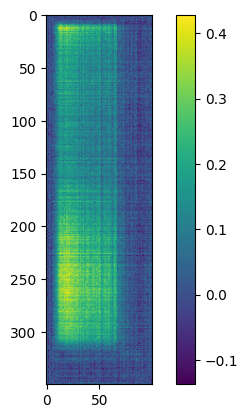

In [54]:
plt.imshow(raw_dyn_mat)
plt.colorbar()

In [55]:
drsa_obj = dRSA(cfg.rdm_metric, RSA_metric=cfg.rsa_metric)
drsa_obj.compute_both_RDM_timeseries(dynamic_means, static_means)
drsa_mat = drsa_obj.compute_dRSA()

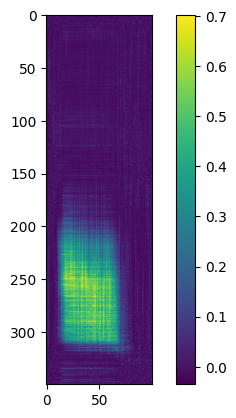

In [56]:
plt.imshow(drsa_mat)
plt.colorbar()

## 6. Visualize consistency and static explanation

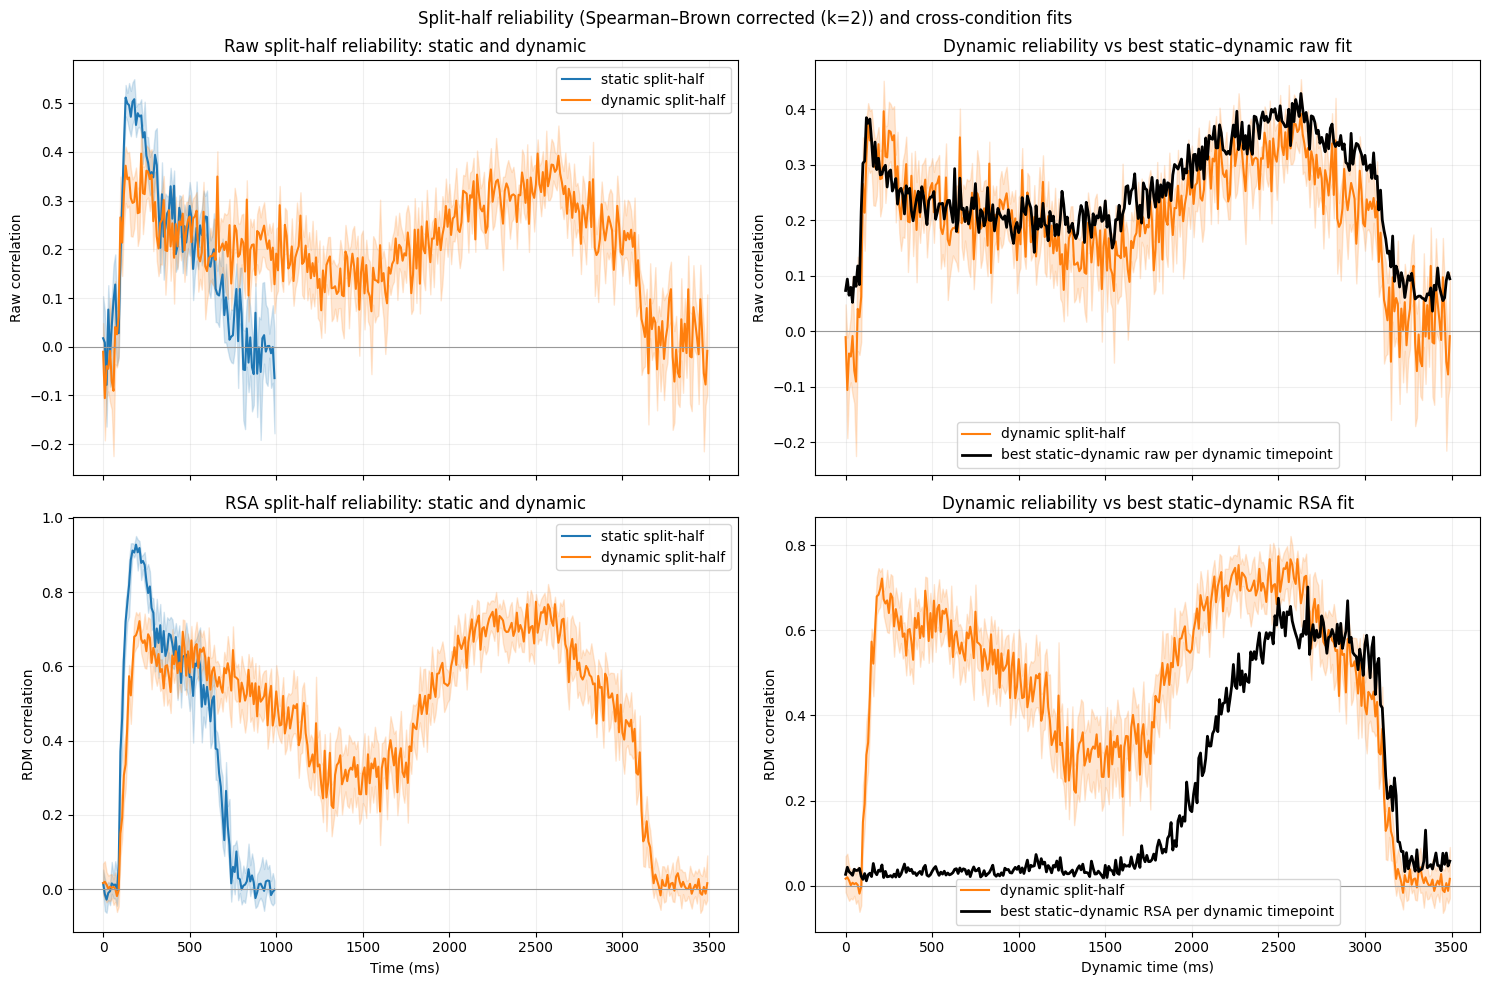

In [57]:
reference_start_ms, reference_end_ms = cfg.static_reference_window_ms
static_reference_indices = (
    (static_times_ms >= reference_start_ms)
    & (static_times_ms <= reference_end_ms)
)
if not static_reference_indices.any():
    raise ValueError("The static reference window contains no samples.")
# end if static_reference_indices
best_static_dynamic_raw = np.nanmax(raw_dyn_mat[:, static_reference_indices], axis=1)
best_static_dynamic_rsa = np.nanmax(drsa_mat[:, static_reference_indices], axis=1)

figure, axes = plt.subplots(2, 2, figsize=(15, 10), sharex="col")
condition_specs = (
    ("static", "tab:blue", static_times_ms),
    ("dynamic", "tab:orange", dynamic_times_ms),
)
for row_index, type_corr in enumerate(("raw", "rsa")):
    for condition, color, times_ms in condition_specs:
        summary = split_half_summary[f"{condition}_{type_corr}"]
        axes[row_index, 0].plot(times_ms, summary["mean"], color=color, label=f"{condition} split-half")
        if cfg.n_split_repeats > 1:
            axes[row_index, 0].fill_between(
                times_ms, summary["lower"], summary["upper"], color=color, alpha=0.18,
            )
        # end if cfg.n_split_repeats
    # end for condition
# end for row_index, type_corr

comparison_specs = (
    (0, split_half_summary["dynamic_raw"], best_static_dynamic_raw, "raw"),
    (1, split_half_summary["dynamic_rsa"], best_static_dynamic_rsa, "RSA"),
)
for row_index, dynamic_summary, best_cross_condition, analysis_label in comparison_specs:
    axes[row_index, 1].plot(
        dynamic_times_ms, dynamic_summary["mean"], color="tab:orange", label="dynamic split-half",
    )
    if cfg.n_split_repeats > 1:
        axes[row_index, 1].fill_between(
            dynamic_times_ms, dynamic_summary["lower"], dynamic_summary["upper"],
            color="tab:orange", alpha=0.18,
        )
    # end if cfg.n_split_repeats
    axes[row_index, 1].plot(
        dynamic_times_ms, best_cross_condition, color="black", linewidth=2,
        label=f"best static–dynamic {analysis_label} per dynamic timepoint",
    )
# end for comparison_specs

axes[0, 0].set(title="Raw split-half reliability: static and dynamic", ylabel="Raw correlation")
axes[0, 1].set(title="Dynamic reliability vs best static–dynamic raw fit", ylabel="Raw correlation")
axes[1, 0].set(title="RSA split-half reliability: static and dynamic", xlabel="Time (ms)", ylabel=f"RDM {cfg.rsa_metric}")
axes[1, 1].set(title="Dynamic reliability vs best static–dynamic RSA fit", xlabel="Dynamic time (ms)", ylabel=f"RDM {cfg.rsa_metric}")
for axis in axes.flat:
    axis.axhline(0, color="0.6", linewidth=0.8)
    axis.legend()
    axis.grid(alpha=0.2)
# end for axis
correction_label = f"Spearman–Brown corrected (k={cfg.spearman_brown_k:g})" if cfg.spearman_brown else "uncorrected"
figure.suptitle(f"Split-half reliability ({correction_label}) and cross-condition fits")
figure.tight_layout()
plt.show()


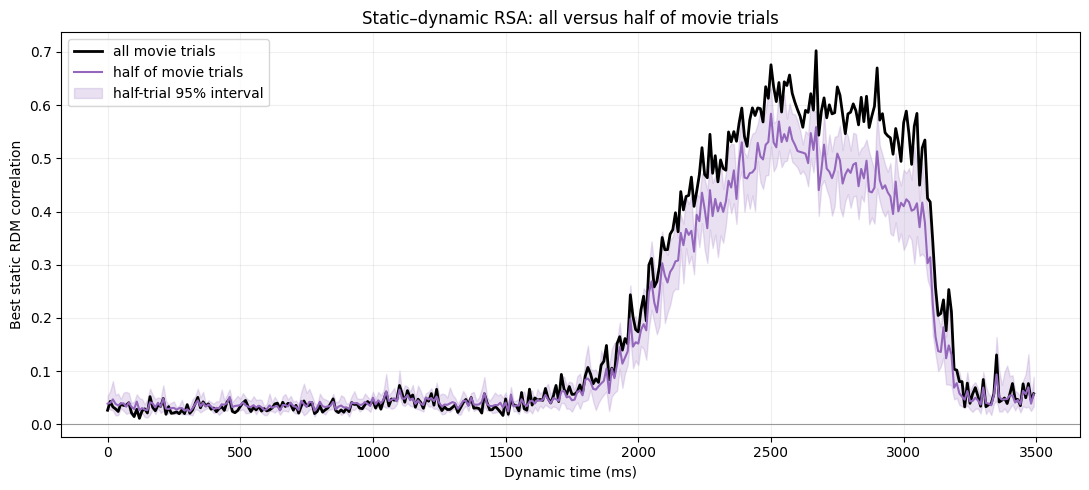

Mean best RSA, all movie trials: 0.202
Mean best RSA, half movie trials: 0.170
Half minus all movie trials: -0.032


In [58]:
half_movie_rng = np.random.default_rng(cfg.random_seed + 1)
half_movie_drsa_mats = []
for repeat_index in range(cfg.n_split_repeats):
    # Keep one randomly selected half of every movie's presentations.
    half_movie_means, _ = split_repetitions(
        dynamic_rasters, dynamic_ids, shared_stimuli, half_movie_rng,
    )
    half_movie_means = TimeSeries(half_movie_means, cfg.new_fs)
    half_movie_drsa = dRSA(cfg.rdm_metric, RSA_metric=cfg.rsa_metric)
    half_movie_drsa.compute_both_RDM_timeseries(half_movie_means, static_means)
    half_movie_drsa_mats.append(half_movie_drsa.compute_dRSA())
# end for repeat_index
half_movie_drsa_mats = np.stack(half_movie_drsa_mats)
half_movie_best_rsa = np.nanmax(
    half_movie_drsa_mats[:, :, static_reference_indices], axis=2,
)

figure, axis = plt.subplots(figsize=(11, 5))
axis.plot(
    dynamic_times_ms, best_static_dynamic_rsa, color="black", linewidth=2,
    label="all movie trials",
)
axis.plot(
    dynamic_times_ms, np.nanmean(half_movie_best_rsa, axis=0),
    color="tab:purple", label="half of movie trials",
)
if cfg.n_split_repeats > 1:
    axis.fill_between(
        dynamic_times_ms, np.nanpercentile(half_movie_best_rsa, 2.5, axis=0),
        np.nanpercentile(half_movie_best_rsa, 97.5, axis=0),
        color="tab:purple", alpha=0.2, label="half-trial 95% interval",
    )
# end if cfg.n_split_repeats
axis.set(
    title="Static–dynamic RSA: all versus half of movie trials",
    xlabel="Dynamic time (ms)", ylabel=f"Best static RDM {cfg.rsa_metric}",
)
axis.axhline(0, color="0.6", linewidth=0.8)
axis.legend()
axis.grid(alpha=0.2)
figure.tight_layout()
plt.show()

full_trial_mean = np.nanmean(best_static_dynamic_rsa)
half_trial_mean = np.nanmean(half_movie_best_rsa)
print(f"Mean best RSA, all movie trials: {full_trial_mean:.3f}")
print(f"Mean best RSA, half movie trials: {half_trial_mean:.3f}")
print(f"Half minus all movie trials: {half_trial_mean - full_trial_mean:+.3f}")
